In [1]:
import seaborn as sns
from TFG_Chollos.utils import conseguir_ruta_general_TFG, get_outliers
import pandas as pd

BASE = conseguir_ruta_general_TFG()

df = pd.read_parquet(BASE / 'data' / 'processed' / 'final' / 'db_final.parquet')

In [ ]:
#Observamos que los tipos de datos sean correctos y los valores únicos de cada columna:

df.info()

print("="*50)
print(f'Analizamos la base de Datos:')
print("="*50)

for col in df.columns:
    print(col, df[col].unique(), '\n')

<class 'pandas.DataFrame'>
RangeIndex: 3123524 entries, 0 to 3123523
Data columns (total 33 columns):
 #   Column               Dtype         
---  ------               -----         
 0   provincia            str           
 1   localidad            str           
 2   titulo               str           
 3   codigo_postal        int32         
 4   latitud              float64       
 5   longitud             float64       
 6   distancia_centro_km  float32       
 7   latitud_centro       float64       
 8   longitud_centro      float64       
 9   tipo                 category      
 10  estrellas            int8          
 11  valoracion_clientes  float32       
 12  n_valoraciones       int64         
 13  url_estancia         str           
 14  Parking              int8          
 15  Parking_gratis       int8          
 16  Gimnasio             int8          
 17  Restaurante          int8          
 18  Piscina              int8          
 19  Piscina_interior     int8       

Hacemos un análisis de todas las variables (normalmente un boxplot), para eliminar outliers:

### Precio

<Axes: ylabel='precio'>

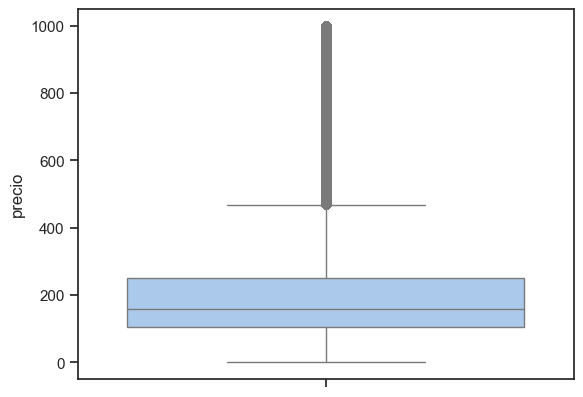

In [4]:
sns.set_theme(style="ticks", palette="pastel")

sns.boxplot(y='precio', data=df)

Como vemos, hay una densidad considerable de outliers (valores anormales, no errores en este caso). Según Tukey (boxplot), los valores 'anormales' son los que están fuera de este umbral [Q1 - 1.5·IQR, Q3 + 1.5·IQR], donde IQR = Q3 - Q1, es decir, en nuestro caso, si está por arriba de 1.5 veces la diferencia entre cuantiles, es un outlier.
         o      ← 468.5€  punto outlier (fuera)

        468€    ← bigote superior real (último valor dentro del límite)                
         |
    _____|____
    |        |
    | Q3=251€|
    |--------|  ← mediana = 100€
    | Q1=106€|
    |________|
         | 
         | 
        20€   ← bigote inferior real (primer valor dentro del límite)

         o    ← 19.5€  punto outlier (posible chollo)

Tukey fue diseñado para detectar anomalías estadísticas, no anomalías de negocio. Un hotel a 500€/noche puede ser perfectamente real (un 5 estrellas en Semana Santa), pero estadísticamente es un outlier porque la mayoría de tus datos son precios más bajos.

Dado que el objetivo del proyecto es predecir chollos (ofertas con muchos servicios a un precio anormalmente bajo), los registros de +500€/noche difícilmente van a ser chollos, y además distorsionarían el modelo al introducir una escala de precios muy diferente a la del rango útil. 

### Tamaño de la Habitación

<Axes: xlabel='tipo', ylabel='tamaño_habitacion'>

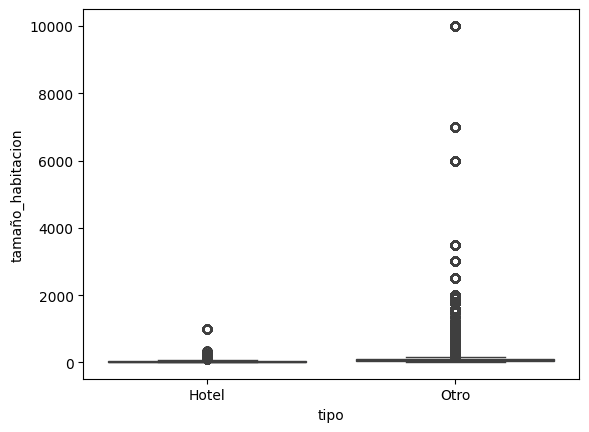

In [2]:
sns.boxplot(x='tipo', y='tamaño_habitacion', data=df)

¿De qué se tratan los valores > 2000 en 'tamaño_habitacion'?
Lo comprobamos

In [ ]:
mas2000 =  df[df['tamaño_habitacion'] > 2000]
pd.set_option('display.max_colwidth', None)
print(mas2000[['url_estancia', 'tamaño_habitacion']].drop_duplicates(subset='url_estancia'))

                                                                                                                                                                                                                              url_estancia  \
86829    https://www.booking.com/hotel/es/la-casa-del-valle-descansar-junto-a-donana-en-plena-naturaleza-manzanilla1.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
98714                                             https://www.booking.com/hotel/es/finca-contrabando-completa-20-pax.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
411220                                                     https://www.booking.com/hotel/es/los-candiles-cantillana2.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0   
958081                                          

Los alojamientos con valores mayores a 2000, son fincas, casas rurales, villas... Estas son categorías que se deberían analizar aparte, dado a su gran diversidad de tipos y de valores elevado. 
Tenemos 2 opciones para gestionar este problema:
- Fijar un umbral mayor al umbral de Tukey para eliminar muchos o todos de estos tipos de alojamiento, que perjudicarían la modelización
- Trabajamos solo con los hoteles que tenemos en la base de datos

In [16]:
n_registros_hoteles = len(df[df['tipo']=='Hotel'])
n_registros_otros = len(df[df['tipo']=='Otro'])
print('Porcentaje del tipo "Hotel":', round(n_registros_hoteles/len(df) * 100,2), '%')
print('Porcentaje del tipo "Otro":', round(n_registros_otros/len(df)*100, 2), '%')

Porcentaje del tipo "Hotel": 7.93 %
Porcentaje del tipo "Otro": 92.07 %


Dado a que los hoteles en la base de datos representan alrededor del 8%, fijamos un umbral de 500m²

In [ ]:
print(f'Registros eliminados por tamaño_habitacion > 500m²: {round(len(df[df['tamaño_habitacion'] > 500])/len(df),2)}% registros')
print(f'Porcentaje de registros eliminados con umbral fijo 150m² en el tamaño de habitación: {round(sum(df['tamaño_habitacion'] > 150)/len(df)*100,2)}% registros')

Registros eliminados por tamaño_habitacion > 500m²: 0.01% registros
Porcentaje de registros eliminados con umbral fijo 150m² en el tamaño de habitación: 8.29% registros
258811


### Distancia de los alojamientos hasta el centro de su localidad

<Axes: ylabel='distancia_centro_km'>

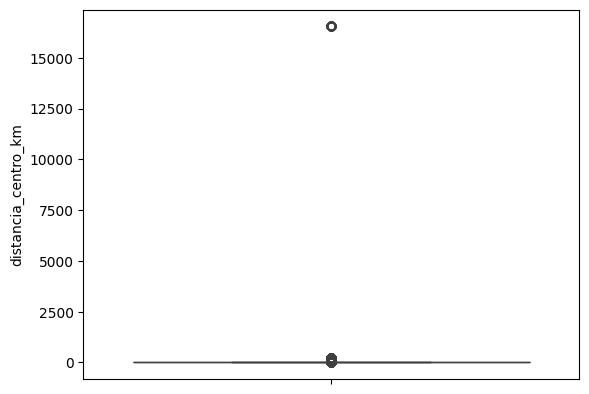

In [7]:
sns.boxplot(y='distancia_centro_km', data=df)

Observamos como la caja de diagrama y bigotes está super aplastada, esto implica que esta variable posee valores bastante parecidos. Hay un valor anormal que debemos eliminar, ya que no hay opción a que un alojamiento esté a más de 15000 km de distancia con respecto al centro de su localidad. Aun así, vemos de qué alojamiento se trata.

In [12]:
df[df['distancia_centro_km']>5000].url_estancia.unique()

<ArrowStringArray>
['https://www.booking.com/hotel/es/casa-rural-el-mirador-guadalcanal.es.html?checkin=2026-09-16&checkout=2026-09-19&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0']
Length: 1, dtype: str

Es un error al añadir la localización del alojamiento, ya que la localización nos envía a las Islas Solomón, y pone que está en Guadalcanal, España.
Volvemos hacer el boxplot sin ese outlier tan extremo:

<Axes: ylabel='distancia_centro_km'>

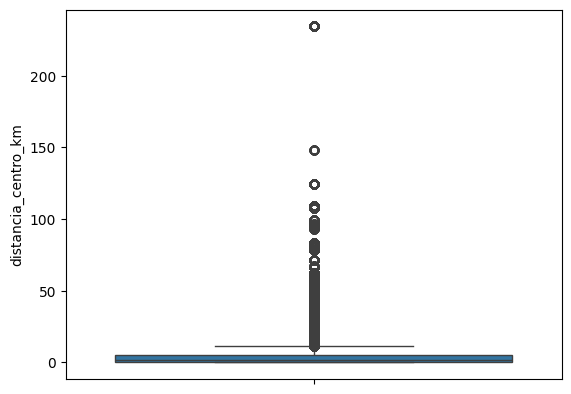

In [18]:
sns.boxplot(y='distancia_centro_km', data=df[df['distancia_centro_km'] < 15000])

Observamos una caja un poco más alta y con valores no tan pronunciados. Aún así, valores por encima de los 30km alejados del centro de localidad sigue siendo excesivo, por lo que toca analizar los outliers.

In [57]:
outliers, big_inf, big_sup = get_outliers(df, 'distancia_centro_km')
print(f'Número de alojamientos con distancia al centro de su localidad, "anormal" (mayor a {big_sup.round(1)} km):', len(outliers['url_estancia'].unique()), '\n')
print(f'Número de registros con distancia al centro de su localidad, "anormal" (mayor a {big_sup.round(1)} km):', len(outliers),'\n')
outliers[outliers['distancia_centro_km'] > 15][['url_estancia', 'localidad', 'distancia_centro_km']].sort_values('distancia_centro_km')

Número de alojamientos con distancia al centro de su localidad, "anormal" (mayor a 11.3 km): 1388 

Número de registros con distancia al centro de su localidad, "anormal" (mayor a 11.3 km): 191798 



,url_estancia,localidad,distancia_centro_km
2801056,https://www.booking.com/hotel/es/elegant-2-bed...,Marbella,15.004000
2801032,https://www.booking.com/hotel/es/elegant-2-bed...,Marbella,15.004000
2801033,https://www.booking.com/hotel/es/elegant-2-bed...,Marbella,15.004000
2801034,https://www.booking.com/hotel/es/elegant-2-bed...,Marbella,15.004000
2801035,https://www.booking.com/hotel/es/elegant-2-bed...,Marbella,15.004000
...,...,...,...
167876,https://www.booking.com/hotel/es/casa-rural-el...,Guadalcanal,16547.658203
167877,https://www.booking.com/hotel/es/casa-rural-el...,Guadalcanal,16547.658203
167878,https://www.booking.com/hotel/es/casa-rural-el...,Guadalcanal,16547.658203
167879,https://www.booking.com/hotel/es/casa-rural-el...,Guadalcanal,16547.658203


In [ ]:
outliers_15 = df[df['distancia_centro_km'] > 15][['localidad', 'provincia', 'titulo', 'latitud', 'longitud', 'latitud_centro', 'longitud_centro', 'distancia_centro_km']]
print('Número de registros con una distancia al centro mayor a 15 km:', len(outliers_15))
outliers_15.drop_duplicates(subset='localidad').sort_values('distancia_centro_km', ascending=False)

Número de registros con una distancia al centro mayor a 15 km: 113563


,localidad,provincia,titulo,latitud,longitud,latitud_centro,longitud_centro,distancia_centro_km
167831,Guadalcanal,Sevilla,Casa Rural El Mirador,-9.577328,160.145581,38.092884,-5.817600,16547.658203
163445,Los Rosales,Sevilla,#1 HABITACIÓN DOBLE con baño compartido SEVILL...,37.594000,-5.737074,37.791119,-3.084208,234.440994
1253065,La Fuente Grande,Granada,La Casita Verde Valle,37.415623,-4.088137,37.952221,-2.548295,148.057007
1283559,Teja,Granada,Casa Cueva Rural LA TEJA 5,37.674174,-2.811064,36.881294,-3.807154,124.658997
1101083,Mures,Granada,La Casa Antonio,37.427389,-3.817340,37.586933,-2.595879,109.193001
...,...,...,...,...,...,...,...,...
1721182,Córdoba,Córdoba,Casa con piscina de agua salada Villa Pepucho 1,37.861638,-4.957895,37.884583,-4.776014,16.167000
2468230,Manilva,Málaga,2174-Huge 3 bedrooms with terrace and pool,36.246255,-5.325703,36.376999,-5.248979,16.080999
1876730,Villaviciosa de Córdoba,Córdoba,Casa Valdevientos Alojamiento Rural,37.980844,-4.883202,38.075626,-5.014633,15.608000
1569285,Cuevas del Almanzora,Almería,"El Calón, mar y montaña",37.309054,-1.706957,37.296135,-1.880722,15.436000


Un alojamiento turístico a más de 15 km del centro de su localidad es raro, si aparece es bastante probable un error de geocodificación, y aunque sean correctos, las fincas y casas rurales muy alejadas del núcleo urbano no son el objeto de estudio del proyecto (chollos en alojamientos turísticos típicos), por lo tanto, fijamos un umbral en 15km de distancia con respecto al centro de su localidad.

In [12]:
#Comprobador de nuevos cambios:

from TFG_Chollos.utils import conseguir_ruta_general_TFG
import pandas as pd

BASE = conseguir_ruta_general_TFG()

df_analizado = pd.read_parquet(BASE / 'data' / 'processed' / 'analisis' / 'db_final_analisis.parquet')
print(df_analizado.loc[:,['precio', 'valoracion_clientes', 'n_valoraciones', 'estrellas', 'tamaño_habitacion', 'distancia_centro_km', 'dias_restantes']].describe())
print(len(df_analizado.loc[df_analizado['dias_restantes'] == -1, :]))

             precio  valoracion_clientes  n_valoraciones     estrellas  \
count  2.603076e+06         2.603076e+06    2.603076e+06  2.603076e+06   
mean   1.675496e+02         8.563249e+00    2.625939e+02  3.085520e+00   
std    9.079181e+01         1.014120e+00    8.183509e+02  9.855044e-01   
min    1.000000e+00         1.000000e+00    0.000000e+00  1.000000e+00   
25%    1.020000e+02         8.200000e+00    6.000000e+00  3.000000e+00   
50%    1.470000e+02         8.700000e+00    2.900000e+01  3.000000e+00   
75%    2.130000e+02         9.200000e+00    1.030000e+02  4.000000e+00   
max    4.680000e+02         1.000000e+01    1.957400e+04  5.000000e+00   

       tamaño_habitacion  distancia_centro_km  dias_restantes  
count       2.603076e+06         2.603076e+06    2.603076e+06  
mean        6.432554e+01         2.593867e+00    1.543306e+02  
std         3.036760e+01         2.977880e+00    9.413286e+01  
min         1.500000e+01         0.000000e+00   -1.000000e+00  
25%         4

In [6]:
#Comprobador de nuevos cambios:

from TFG_Chollos.utils import conseguir_ruta_general_TFG
import pandas as pd

BASE = conseguir_ruta_general_TFG()

df_codificado = pd.read_parquet(BASE / 'data' / 'processed' / 'modelizacion' / 'db_final_codificada.parquet')
df_codificado

,provincia,localidad,distancia_centro_km,estrellas,valoracion_clientes,n_valoraciones,Parking,Parking_gratis,Gimnasio,Restaurante,...,Terraza,Baño_privado,tamaño_habitacion,dias_restantes,es_finde,es_domingo,precio,tipo_Hotel,mes_disponible,dia_disponible
0,4,378,0.454,3,8.3,4033,0,0,0,0,...,0,1,15,2,1,0,108,True,5,16
1,4,378,0.454,3,8.3,4033,0,0,0,0,...,0,1,15,3,0,1,50,True,5,17
2,4,378,0.454,3,8.3,4033,0,0,0,0,...,0,1,15,4,0,0,72,True,5,18
3,4,378,0.454,3,8.3,4033,0,0,0,0,...,0,1,15,5,0,0,63,True,5,19
4,4,378,0.454,3,8.3,4033,0,0,0,0,...,0,1,15,6,0,0,63,True,5,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2603071,6,514,7.912,1,8.5,0,0,0,0,0,...,1,0,120,360,0,0,67,False,5,11
2603072,6,514,7.912,1,8.5,0,0,0,0,0,...,1,0,120,361,0,0,67,False,5,12
2603073,6,514,7.912,1,8.5,0,0,0,0,0,...,1,0,120,362,0,0,67,False,5,13
2603074,6,514,7.912,1,8.5,0,0,0,0,0,...,1,0,120,363,1,0,67,False,5,14
